In [14]:
import torch
from torch.nn import Linear,MSELoss    # 线性回归模型，损失函数
from torch.optim import SGD   # 优化器
from torch.utils.data import DataLoader,TensorDataset
from sklearn.datasets import make_regression   # 生成回归数据集
from matplotlib import pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

In [ ]:
def create_dateset():
    # 创建数据
    # n_samples: 样本数量
    # n_features: 特征数量
    # bias: 偏置
    # coef: 系数
    # noise: 噪声
    x,y,coef = make_regression(n_samples=100,n_features=1,bias=1.5,coef=True,noise=10)
    x = torch.tensor(x,dtype=torch.float32)
    y = torch.tensor(y,dtype=torch.float32)
    return x,y,coef # coef: 线性回归的系数 y = x * coef + bias + noise

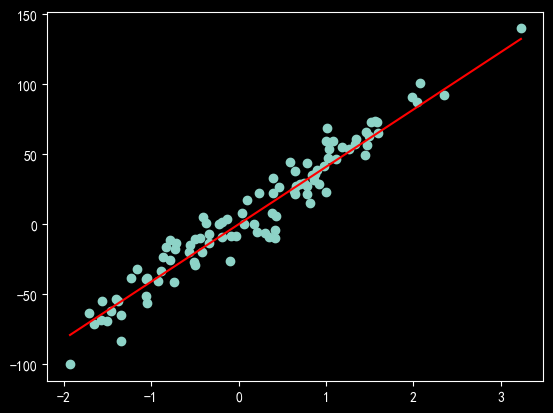

In [12]:
x,y,coef = create_dateset()
# print(x,y)
# print(x.shape,y.shape,coef)
plt.scatter(x, y) # 绘制散点图
# 绘制拟合直线
x1 = torch.linspace(x.min(), x.max(), 1000)
y1 = torch.tensor([v * coef for v in x1])
plt.plot(x1, y1,color='red')
plt.show()

In [16]:
# 设备选择
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# 创建模型
model = Linear(in_features=1, out_features=1).to(device)
# 创建损失函数
loss_fn = MSELoss().to(device)
# 创建优化器
optimizer = SGD(model.parameters(), lr=0.01)
# 数据集
# shuffle: 数据集是否打乱
data_loader = DataLoader(dataset=TensorDataset(x,y), batch_size=10, shuffle=True)

In [ ]:
epochs = 100  # 训练的次数
loss_epoch = []   # 记录损失
for epoch in range(epochs):
    total_loss = 0.0  # 损失初始化为0
    train_samples = 0  # 训练样本数初始化为0
    for train_x,train_y in data_loader:
        # 将数据送入GPU
        train_x, train_y = train_x.to(device), train_y.to(device)
        # 将一个batch的训练数据送入模型
        y_pred = model(train_x.type(torch.float32))
        # 计算损失
        loss = loss_fn(y_pred, train_y.reshape(-1,1).type(torch.float32))
        # 梯度清零
        optimizer.zero_grad()
        # 自动微分
        loss.backward()
        # 优化器更新参数
        optimizer.step()
        # 累积损失和样本数
        total_loss += loss.item()
        train_samples += len(train_y)
    # 计算epoch平均
    epoch_loss = total_loss / train_samples
    # 记录平均损失
    loss_epoch.append(epoch_loss)

In [20]:
train_y.shape

torch.Size([10])

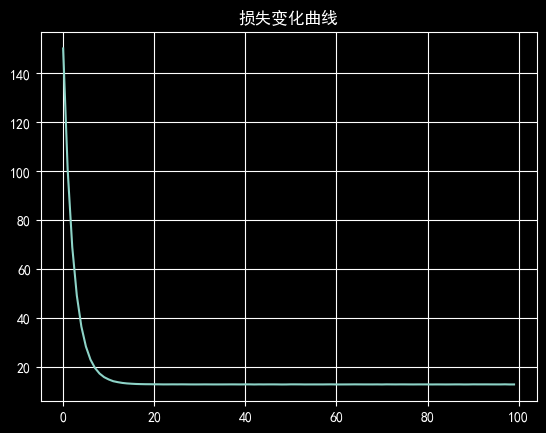

In [24]:
plt.plot(range(epochs),loss_epoch)
plt.title('损失变化曲线')
plt.grid()
plt.show()

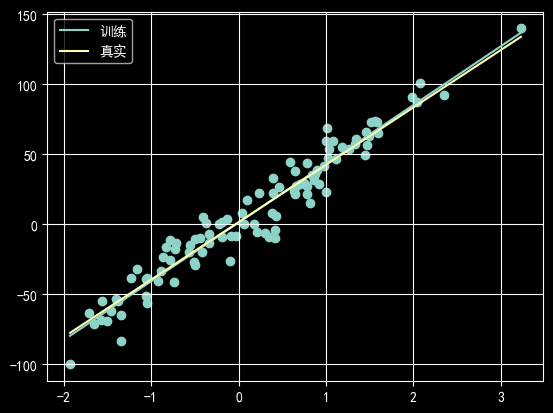

In [25]:
# 绘制散点点
plt.scatter(x,y)
# 绘制拟合直线
x = torch.linspace(x.min(), x.max(), 100)
y1 = torch.tensor([v * model.weight + model.bias for v in x]) # 预测值
y2 = torch.tensor([v * coef + 1.5 for v in x])
plt.plot(x, y1, label='训练')
plt.plot(x, y2, label='真实')
plt.grid()
plt.legend()
plt.show()